In [1]:
import os

from cifar2 import ds_train

os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, metrics, optimizers, callbacks

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.]),
 [Text(-10.0, 0, '2020-03-01'),
  Text(0.0, 0, '2020-01-24'),
  Text(10.0, 0, '2020-02-03'),
  Text(20.0, 0, '2020-02-13'),
  Text(30.0, 0, '2020-02-23'),
  Text(40.0, 0, '2020-03-04'),
  Text(50.0, 0, '')])

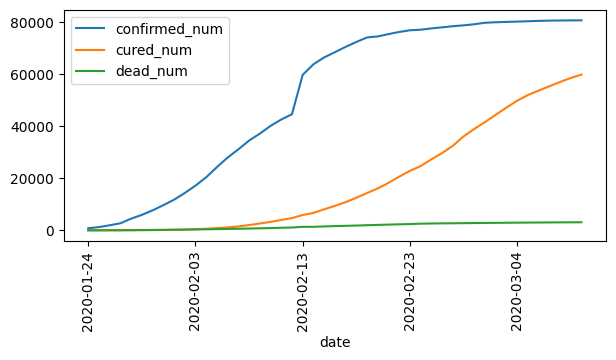

In [2]:
df = pd.read_csv("data/covid-19.csv", sep="\t")
df.plot(x="date", y=["confirmed_num", "cured_num", "dead_num"], figsize=(7, 3))
plt.xticks(rotation=90)

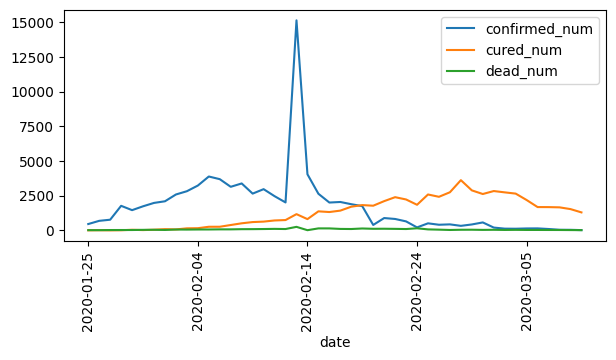

In [3]:
dfdata = df.set_index("date")
dfdiff = dfdata.diff(periods=1).dropna()
dfdiff = dfdiff.reset_index("date")

dfdiff.plot(x="date", y=["confirmed_num", "cured_num", "dead_num"], figsize=(7, 3))
plt.xticks(rotation=90)
dfdiff = dfdiff.drop("date", axis=1).astype("float32")

In [4]:
WINDOW_SIZE = 8

def batch_dataset(dataset):
    dataset_batched = dataset.batch(WINDOW_SIZE, drop_remainder=True)
    return dataset_batched


ds_data = tf.data.Dataset.from_tensor_slices(tf.constant(dfdiff.values, dtype=tf.float32))\
    .window(WINDOW_SIZE, shift=1).flat_map(batch_dataset)

ds_label = tf.data.Dataset.from_tensor_slices(tf.constant(dfdiff.values[:WINDOW_SIZE], dtype=tf.float32))

ds_train = tf.data.Dataset.zip((ds_data, ds_label)).batch(38).cache()

In [6]:
class Block(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, x_input, x):
        x_out = tf.maximum((1 + x) * x_input[:, -1, :], 0,0)
        return x_out

    def get_config(self):
        return super().get_config()

In [7]:
tf.keras.backend.clear_session()

x_input = layers.Input(shape=(None, 3), dtype=tf.float32)
x = layers.LSTM(3, return_sequences=True, input_shape=(None, 3))(x_input)
x = layers.LSTM(3, return_sequences=True, input_shape=(None, 3))(x)
x = layers.LSTM(3, return_sequences=True, input_shape=(None, 3))(x)
x = layers.LSTM(3, return_sequences=True)(x)
x = layers.Dense(3)(x)


x = Block()(x_input, x)
model = models.Model(inputs=[x_input], outputs=[x])
model.summary()

/home/fernando/PycharmProjects/tf-keras/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, None, 3)   │         84 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 3)   │         84 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 3)   │         84 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, None, 3)   │         84 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 3)   │         12 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block (Block)       │ (None, None, 3)   │          0 │ input_layer[0][0… │
│                     │                   │            │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 348 (1.36 KB)

 Trainable params: 348 (1.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
class MSPE(losses.Loss):
    def call(self,y_true,y_pred):
        err_percent = (y_true - y_pred)**2/(tf.maximum(y_true**2,1e-7))
        mean_err_percent = tf.reduce_mean(err_percent)
        return mean_err_percent

    def get_config(self):
        config = super(MSPE, self).get_config()
        return config

In [9]:
import os
import datetime

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer,loss=MSPE(name = "MSPE"))

stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
logdir = os.path.join('data', 'autograph', stamp)


tb_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor="loss",factor = 0.5, patience = 100)
stop_callback = tf.keras.callbacks.EarlyStopping(monitor = "loss", patience= 200)
callbacks_list = [tb_callback,lr_callback,stop_callback]

history = model.fit(ds_train,epochs=500,callbacks = callbacks_list)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 275.0482 - learning_rate: 0.0100
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 257.6534 - learning_rate: 0.0100
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 243.6580 - learning_rate: 0.0100
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 230.2087 - learning_rate: 0.0100
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 216.7555

/home/fernando/PycharmProjects/tf-keras/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 216.7555 - learning_rate: 0.0100
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 203.0515 - learning_rate: 0.0100
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 188.9695 - learning_rate: 0.0100
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 174.4526 - learning_rate: 0.0100
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 159.4765 - learning_rate: 0.0100
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 144.0442 - learning_rate: 0.0100
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 128.2019 - learning_rate: 0.0100
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 112.0571 - learning_rate: 0.0100
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 95.7933 - learning_rate: 0.0100
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 79.6840 - learning_rate: 0.0100
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 64.0802 - learning_rate: 0.0100
Epoch 16

In [10]:
def plot_metric(history, metric):
    train_metrics = history.history[metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.title('Training '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric])
    plt.show()

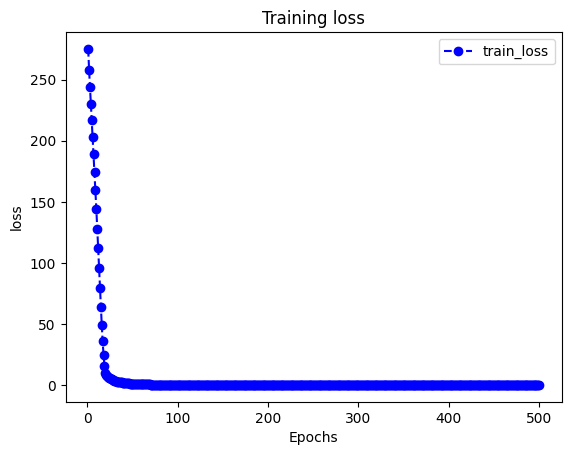

In [11]:
plot_metric(history,"loss")

In [12]:
dfresult = dfdiff[["confirmed_num","cured_num","dead_num"]].copy()
dfresult.tail()

,confirmed_num,cured_num,dead_num
41,143.0,1681.0,30.0
42,99.0,1678.0,28.0
43,44.0,1661.0,27.0
44,40.0,1535.0,22.0
45,19.0,1297.0,17.0
